In [2]:
import requests
import pandas as pd
import datetime

In [3]:
api_key = '4d876a999dfd601d66668e8d1b243d42' 

In [4]:
lat = 18.6215
lon = 73.9126

In [5]:
api_url = f"https://api.openweathermap.org/data/2.5/forecast?lat={lat}&lon={lon}&appid={api_key}"

In [6]:
response = requests.get(api_url)
weather_data = response.json()
weather_data.keys()
len(weather_data['list'])
weather_data['list'][0]['weather'][0]['description']

'scattered clouds'

In [7]:
# Getting the data from dictionary and taking into one variable 
# Extract relevant weather attributes using list comprehension
temperatures = [item['main']['temp'] for item in weather_data['list']] 

# It will extract all values (40) and putting into one variable
timestamps = [pd.to_datetime(item['dt'], unit='s') for item in weather_data['list']]
temperature = [item['main']['temp'] for item in weather_data['list']]
humidity = [item['main']['humidity'] for item in weather_data['list']]
wind_speed = [item['wind']['speed'] for item in weather_data['list']]
weather_description = [item['weather'][0]['description'] for item in weather_data['list']]

In [8]:
# Create a pandas DataFrame with the extracted weather data
weather_df = pd.DataFrame({'Timestamp': timestamps, 
                           'Temperature': temperatures, 
                           'humidity': humidity, 
                           'wind_speed':wind_speed,
                           'weather_description': weather_description})

In [9]:
# Set the Timestamp column as the DataFrame's index
weather_df.set_index('Timestamp', inplace=True)
max_temp = weather_df['Temperature'].max()
print(f"Maximum Temperature - {max_temp}")
min_temp = weather_df['Temperature'].min()
print(f"Minimum Temperature - {min_temp}")

Maximum Temperature - 312.58
Minimum Temperature - 296.58


In [10]:
weather_df.fillna(0, inplace=True)

,Temperature,humidity,wind_speed,weather_description
Timestamp,,,,
2026-05-12 12:00:00,311.24,30,6.36,scattered clouds
2026-05-12 15:00:00,309.16,32,5.98,scattered clouds
2026-05-12 18:00:00,306.11,32,5.08,broken clouds
2026-05-12 21:00:00,302.26,40,4.51,overcast clouds
2026-05-13 00:00:00,301.21,45,4.67,overcast clouds
2026-05-13 03:00:00,303.26,35,3.19,overcast clouds
2026-05-13 06:00:00,309.90,18,4.91,overcast clouds
2026-05-13 09:00:00,312.58,17,7.88,overcast clouds
2026-05-13 12:00:00,308.95,28,8.79,overcast clouds


In [11]:
weather_df['Temperature'] = weather_df['Temperature'].apply(lambda x: x - 273.15 if isinstance(x, float)else x)

In [12]:
print(weather_df)

                     Temperature  humidity  wind_speed weather_description
Timestamp                                                                 
2026-05-12 12:00:00        38.09        30        6.36    scattered clouds
2026-05-12 15:00:00        36.01        32        5.98    scattered clouds
2026-05-12 18:00:00        32.96        32        5.08       broken clouds
2026-05-12 21:00:00        29.11        40        4.51     overcast clouds
2026-05-13 00:00:00        28.06        45        4.67     overcast clouds
2026-05-13 03:00:00        30.11        35        3.19     overcast clouds
2026-05-13 06:00:00        36.75        18        4.91     overcast clouds
2026-05-13 09:00:00        39.43        17        7.88     overcast clouds
2026-05-13 12:00:00        35.80        28        8.79     overcast clouds
2026-05-13 15:00:00        30.89        38        7.04     overcast clouds
2026-05-13 18:00:00        28.30        47        6.36       broken clouds
2026-05-13 21:00:00      

In [13]:
import matplotlib.pyplot as plt
daily_mean_temp = weather_df['Temperature'].resample('D').mean()
daily_mean_humidity = weather_df['humidity'].resample('D').mean()
daily_mean_wind_speed = weather_df['wind_speed'].resample('D').mean()

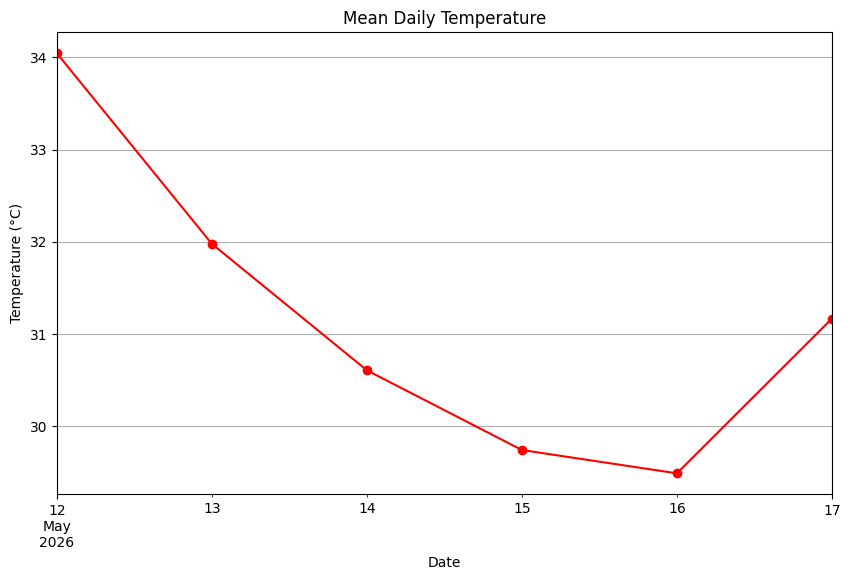

In [14]:
# Plot the mean daily temperature over time (Line plot)
plt.figure(figsize=(10, 6))
daily_mean_temp.plot(color='red', linestyle='-', marker='o')
plt.title('Mean Daily Temperature')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.grid(True)
plt.show()

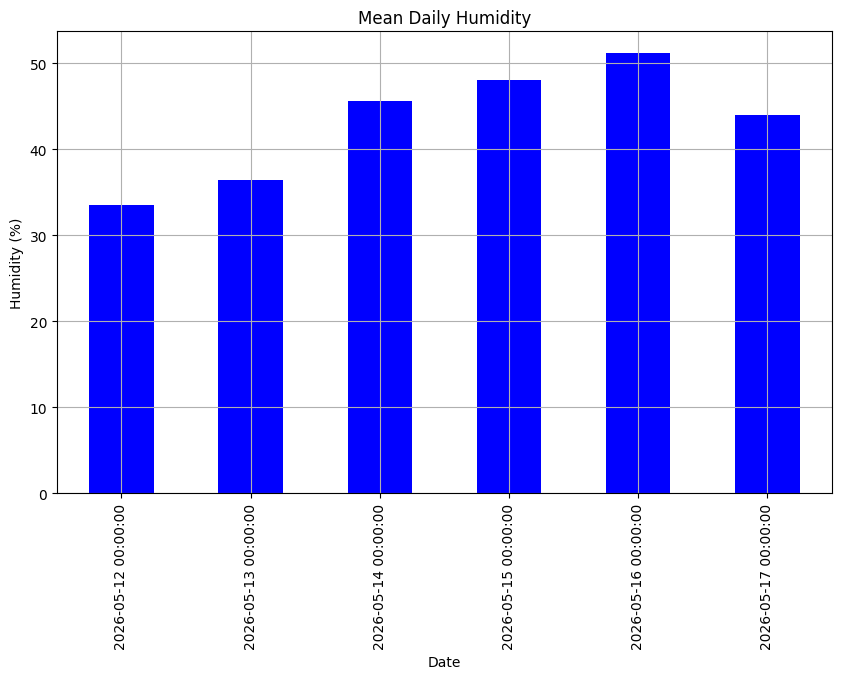

In [15]:
# Plot the mean daily humidity over time (Bar plot)
plt.figure(figsize=(10, 6))
daily_mean_humidity.plot(kind='bar', color='blue')
plt.title('Mean Daily Humidity')
plt.xlabel('Date')
plt.ylabel('Humidity (%)')
plt.grid(True)
plt.show()

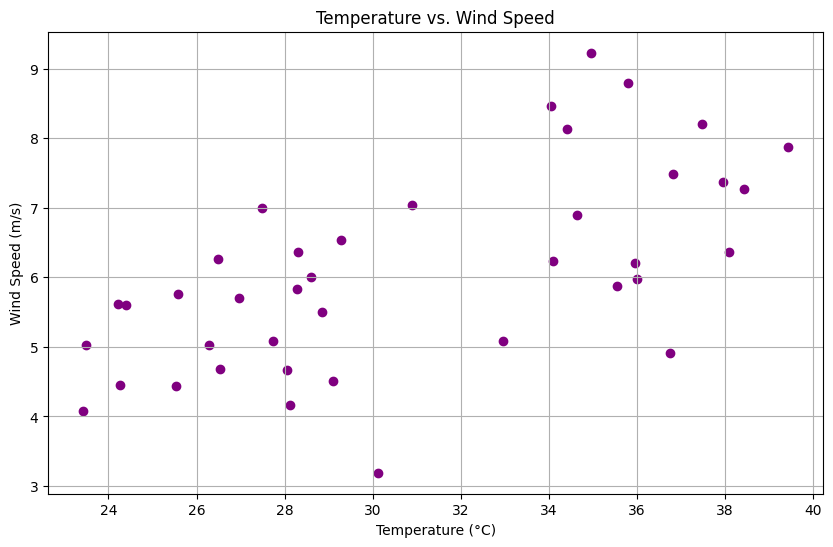

In [16]:
# Plot the relationship between temperature and wind speed (Scatter plot)
plt.figure(figsize=(10, 6))
plt.scatter(weather_df['Temperature'], weather_df['wind_speed'], color='purple')
plt.title('Temperature vs. Wind Speed')
plt.xlabel('Temperature (°C)')
plt.ylabel('Wind Speed (m/s)')
plt.grid(True)
plt.show()

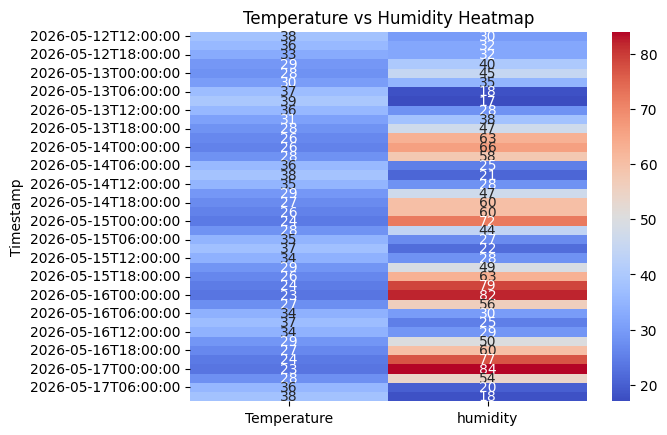

In [17]:
# Heatmap
import seaborn as sns
heatmap_data = weather_df[['Temperature', 'humidity']]
sns.heatmap(heatmap_data, annot=True, cmap='coolwarm')
plt.title('Temperature vs Humidity Heatmap')
plt.show()

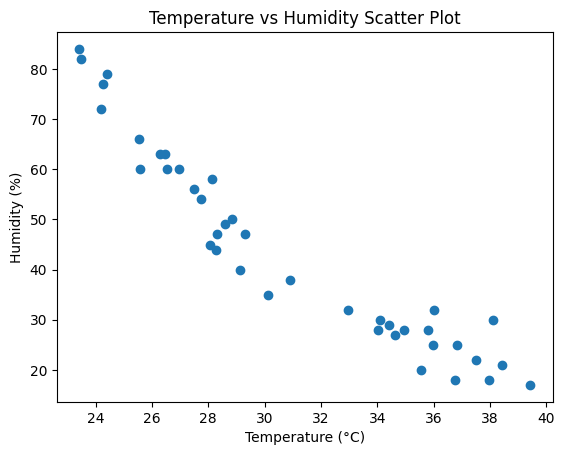

In [18]:
# Create a scatter plot to visualize the relationship between temperature and humidity
plt.scatter(weather_df['Temperature'], weather_df['humidity'])
plt.xlabel('Temperature (°C)')
plt.ylabel('Humidity (%)')
plt.title('Temperature vs Humidity Scatter Plot')
plt.show()

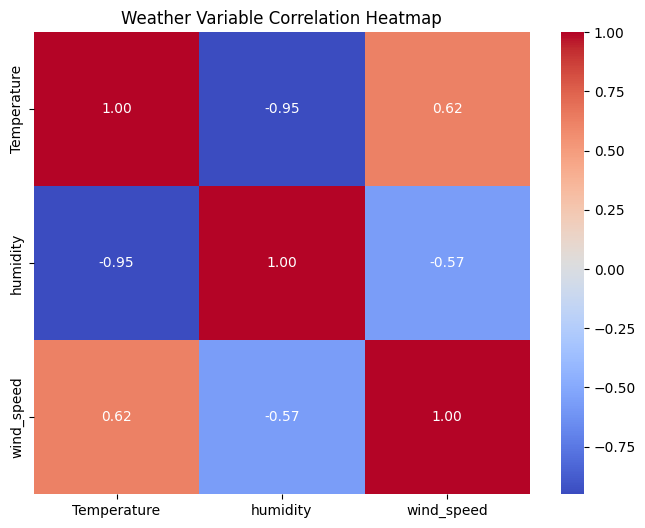

In [19]:
import seaborn as sns

# Calculate the correlation between numeric columns
corr = weather_df[['Temperature', 'humidity', 'wind_speed']].corr()

# Plot the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Weather Variable Correlation Heatmap')
plt.show()